In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier  
from sklearn.preprocessing import LabelEncoder
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# the path where the project root is at
BASE_ENV = Path().resolve().parent

In [3]:
df = pd.read_csv(BASE_ENV / 'data/raw/UNSW-NB15_1.csv')
df.head()

/tmp/ipykernel_45287/3269063629.py:1: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(BASE_ENV / 'data/raw/UNSW-NB15_1.csv')


,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0.17,3,7,1,3.1,1.1,1.2,1.3,Unnamed: 47,0.18
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568,312,31,...,0,2,4,2,3,1,1,2,NaN,0


In [4]:
columns_to_drop = []

In [38]:
# current dataset's column name
df.columns.tolist()

['dur',
 'sbytes',
 'dbytes',
 'sttl',
 'dttl',
 'sloss',
 'dloss',
 'Sload',
 'Dload',
 'Spkts',
 'Dpkts',
 'swin',
 'dwin',
 'stcpb',
 'dtcpb',
 'smeansz',
 'dmeansz',
 'trans_depth',
 'res_bdy_len',
 'Sjit',
 'Djit',
 'Sintpkt',
 'Dintpkt',
 'tcprtt',
 'synack',
 'ackdat',
 'is_sm_ips_ports',
 'ct_state_ttl',
 'ct_flw_http_mthd',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_srv_src',
 'ct_srv_dst',
 'ct_dst_ltm',
 'ct_src_ ltm',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'ct_dst_src_ltm',
 'attack_cat',
 'proto_a/n',
 'proto_aes-sp3-d',
 'proto_any',
 'proto_argus',
 'proto_aris',
 'proto_arp',
 'proto_ax.25',
 'proto_bbn-rcc',
 'proto_bna',
 'proto_br-sat-mon',
 'proto_cbt',
 'proto_cftp',
 'proto_chaos',
 'proto_compaq-peer',
 'proto_cphb',
 'proto_cpnx',
 'proto_crtp',
 'proto_crudp',
 'proto_dcn',
 'proto_ddp',
 'proto_ddx',
 'proto_dgp',
 'proto_egp',
 'proto_eigrp',
 'proto_emcon',
 'proto_encap',
 'proto_etherip',
 'proto_fc',
 'proto_fire',
 'proto_ggp',
 'proto_gmtp',
 'proto_gre',

In [6]:
# load column names
df_columns = pd.read_csv(BASE_ENV / 'data/raw/NUSW-NB15_features.csv', encoding='windows-1252')

In [7]:
df_columns

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [8]:
# checking if rows in the dataframe is equal to the column count
df.columns.value_counts().equals(df_columns['Name'].value_counts())

False

In [9]:
df_col_names = df_columns['Name']
df_col_names

0                srcip
1                sport
2                dstip
3               dsport
4                proto
5                state
6                  dur
7               sbytes
8               dbytes
9                 sttl
10                dttl
11               sloss
12               dloss
13             service
14               Sload
15               Dload
16               Spkts
17               Dpkts
18                swin
19                dwin
20               stcpb
21               dtcpb
22             smeansz
23             dmeansz
24         trans_depth
25         res_bdy_len
26                Sjit
27                Djit
28               Stime
29               Ltime
30             Sintpkt
31             Dintpkt
32              tcprtt
33              synack
34              ackdat
35     is_sm_ips_ports
36        ct_state_ttl
37    ct_flw_http_mthd
38        is_ftp_login
39          ct_ftp_cmd
40          ct_srv_src
41          ct_srv_dst
42          ct_dst_ltm
43         

In [10]:
df.columns = df_col_names.to_list()

In [11]:
df.head()

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568,312,31,...,0,2,4,2,3,1,1,2,NaN,0


In [12]:
df.shape

(700000, 49)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 49 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   srcip             700000 non-null  object 
 1   sport             700000 non-null  object 
 2   dstip             700000 non-null  object 
 3   dsport            700000 non-null  object 
 4   proto             700000 non-null  object 
 5   state             700000 non-null  object 
 6   dur               700000 non-null  float64
 7   sbytes            700000 non-null  int64  
 8   dbytes            700000 non-null  int64  
 9   sttl              700000 non-null  int64  
 10  dttl              700000 non-null  int64  
 11  sloss             700000 non-null  int64  
 12  dloss             700000 non-null  int64  
 13  service           700000 non-null  object 
 14  Sload             700000 non-null  float64
 15  Dload             700000 non-null  float64
 16  Spkts             70

In [14]:
df = df.replace('-', np.nan)

In [15]:
# Fill the missing values with a string placeholder
df['service'] = df['service'].fillna('Unknown')

# Verify it worked (should print 0)
print(f"Remaining NaNs in service: {df['service'].isnull().sum()}")

# Look at the new distribution
print(df['service'].value_counts())

Remaining NaNs in service: 0
service
Unknown     430656
dns         121169
http         55858
ftp-data     37305
smtp         23588
ftp          16531
ssh          14636
pop3           206
ssl             20
snmp            14
radius           7
dhcp             7
irc              3
Name: count, dtype: int64


In [16]:
df.isnull().sum()

srcip                    0
sport                    2
dstip                    0
dsport                   7
proto                    0
state                    0
dur                      0
sbytes                   0
dbytes                   0
sttl                     0
dttl                     0
sloss                    0
dloss                    0
service                  0
Sload                    0
Dload                    0
Spkts                    0
Dpkts                    0
swin                     0
dwin                     0
stcpb                    0
dtcpb                    0
smeansz                  0
dmeansz                  0
trans_depth              0
res_bdy_len              0
Sjit                     0
Djit                     0
Stime                    0
Ltime                    0
Sintpkt                  0
Dintpkt                  0
tcprtt                   0
synack                   0
ackdat                   0
is_sm_ips_ports          0
ct_state_ttl             0
c

In [17]:
df['attack_cat'] = df['attack_cat'].replace(np.nan, 'Benign')

In [18]:
df['attack_cat'].value_counts()

attack_cat
Benign            677785
Generic             7522
Exploits            5409
 Fuzzers            5051
Reconnaissance      1759
DoS                 1167
Backdoors            534
Analysis             526
Shellcode            223
Worms                 24
Name: count, dtype: int64

In [19]:
(df['attack_cat'] != 'Benign').equals(df['Label'] == 1)

True

In [20]:
# checking duplicates
duplicate_names = df.columns[df.columns.str.contains(r'\.\d+$')]
print("Duplicate column names:")
print(duplicate_names.tolist())

columns_to_drop.extend(duplicate_names.tolist())

Duplicate column names:
[]


In [21]:
# checking hidden feature colnes 
hidden_clones = set()
for i in range(df.shape[1]):
    col_1 = df.iloc[:, i]
    
    for j in range(i + 1, df.shape[1]):
        col_2 = df.iloc[:, j]
        
        if col_1.equals(col_2):
            hidden_clones.add(df.columns[j])

print(f"clone columns: {hidden_clones}")
columns_to_drop.extend(list(hidden_clones))

clone columns: set()


In [22]:
# checking logical negative values
negative_values = (df.select_dtypes(include=[np.number]) < 0).sum()
print("Columns containing negative values:")
print(negative_values[negative_values > 0])

Columns containing negative values:
Series([], dtype: int64)


In [23]:
df.columns

Index(['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes',
       'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload',
       'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz',
       'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime',
       'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat',
       'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login',
       'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat',
       'Label'],
      dtype='object')

In [24]:

# 2. Split the dataset into two temporary DataFrames
df_normal = df[df['attack_cat'] == 'Benign']
df_attacks = df[df['attack_cat'] != 'Benign']

# Calculate total number of attacks (should be around 22,215 based on your image)
total_attacks = len(df_attacks)

print(f"Original Normal count: {len(df_normal)}")
print(f"Original Attack count: {total_attacks}")

# 3. Undersample the Normal traffic to a 2:1 ratio
# (If you want a 1:1 ratio, just remove the * 2)
df_normal_undersampled = df_normal.sample(n=total_attacks * 2, random_state=42)

# 4. Recombine the datasets into your new, balanced master DataFrame
df_balanced = pd.concat([df_normal_undersampled, df_attacks])

# 5. Shuffle the rows thoroughly so the model doesn't read all normal packets first

Original Normal count: 677785
Original Attack count: 22215


In [25]:
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [26]:
# drop necessary noise
df = df.drop(['srcip', 'dstip', 'sport', 'dsport', 'Stime', 'Ltime'], axis=1, errors='ignore')
columns_to_drop.extend(['srcip', 'dstip', 'sport', 'dsport', 'Stime', 'Ltime'])

In [27]:
# dropping label to be able to generalize the multiclass models later 
df = df.drop('Label', axis=1, errors='ignore')
columns_to_drop.append('Label')

In [28]:
df.head()

,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,...,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat
0,udp,CON,0.001041,146,178,31,29,0,0,dns,...,0,0,6,4,4,5,1,1,2,Benign
1,udp,CON,0.001020,146,178,31,29,0,0,dns,...,0,0,3,1,1,4,1,1,1,Benign
2,tcp,FIN,0.168899,37914,3380,31,29,19,8,smtp,...,0,0,2,2,5,3,1,1,1,Benign
3,tcp,FIN,1.157755,16654,860376,31,29,2,273,http,...,0,0,1,1,2,1,1,1,1,Benign
4,udp,INT,0.000007,114,0,254,0,0,0,dns,...,0,0,16,16,7,7,7,4,7,Generic


## Correlation Testing

In [29]:
df['attack_cat'] = df['attack_cat'].apply(lambda x: 0 if x == 'Benign' else 1)

In [30]:
df['attack_cat'].value_counts()

attack_cat
0    44430
1    22215
Name: count, dtype: int64

In [31]:
# 1. Identify the feature columns to encode
categorical_features = ['proto', 'state', 'service']

print(f"Shape before One-Hot Encoding: {df.shape}")

# 2. Use get_dummies to create a binary column for every protocol/state
# drop_first=True prevents the dummy variable trap
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print(f"Shape after One-Hot Encoding: {df.shape}")

# Now you can look at the new columns! 
# You will see things like 'proto_tcp', 'proto_udp' containing only 0s and 1s.

Shape before One-Hot Encoding: (66645, 42)
Shape after One-Hot Encoding: (66645, 192)


In [32]:
X = df.copy()
y = X['attack_cat']
X = X.drop(columns=['attack_cat'])

In [33]:
rf_checker = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_checker.fit(X, y)

,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
important_features = pd.Series(rf_checker.feature_importances_, index=X.columns)
important_features = important_features.sort_values(ascending=False)

In [35]:
dead_correlation_columns_RF = important_features[important_features <= 0.001].to_dict()
print("Features with low importance according to Random Forest:")
print(dead_correlation_columns_RF)

Features with low importance according to Random Forest:
{'ct_dst_src_ltm': 0.0009756422335423766, 'proto_arp': 0.0008975240909126185, 'ct_src_dport_ltm': 0.0006861950071356925, 'ct_srv_src': 0.0005566030613701989, 'service_dns': 0.00040760426519057154, 'service_pop3': 0.00035807886768625917, 'dtcpb': 0.0002566574489791191, 'state_REQ': 0.0002481544533791268, 'proto_ospf': 0.00023366364100393835, 'service_http': 0.00021115235324793057, 'proto_tcp': 0.00020336908600635073, 'ct_ftp_cmd': 0.0001850067646852684, 'service_smtp': 0.0001264022158919776, 'proto_sctp': 9.691719956074348e-05, 'state_URH': 8.751365985089037e-05, 'proto_icmp': 8.237502624076406e-05, 'trans_depth': 7.745873300438821e-05, 'ct_flw_http_mthd': 7.522993550605291e-05, 'is_ftp_login': 5.225177961664539e-05, 'proto_swipe': 5.0380903816668414e-05, 'dwin': 4.758060703202195e-05, 'proto_sun-nd': 3.4269149156223946e-05, 'proto_mobile': 2.8501213660000446e-05, 'proto_unas': 2.6277985895929026e-05, 'state_RST': 2.44448397356130

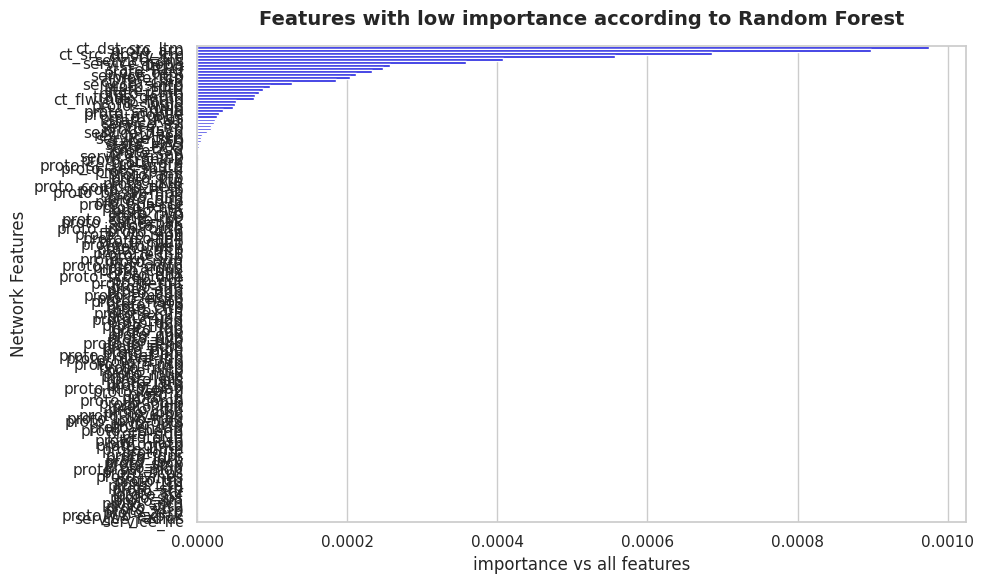

In [36]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(x=list(dead_correlation_columns_RF.values()), y=list(dead_correlation_columns_RF.keys()), color='blue')
plt.title("Features with low importance according to Random Forest", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("importance vs all features", fontsize=12)
plt.ylabel("Network Features", fontsize=12)

plt.tight_layout()
plt.show()

In [37]:
columns_to_drop.extend(list(dead_correlation_columns_RF.keys()))
columns_to_drop

['srcip',
 'dstip',
 'sport',
 'dsport',
 'Stime',
 'Ltime',
 'Label',
 'ct_dst_src_ltm',
 'proto_arp',
 'ct_src_dport_ltm',
 'ct_srv_src',
 'service_dns',
 'service_pop3',
 'dtcpb',
 'state_REQ',
 'proto_ospf',
 'service_http',
 'proto_tcp',
 'ct_ftp_cmd',
 'service_smtp',
 'proto_sctp',
 'state_URH',
 'proto_icmp',
 'trans_depth',
 'ct_flw_http_mthd',
 'is_ftp_login',
 'proto_swipe',
 'dwin',
 'proto_sun-nd',
 'proto_mobile',
 'proto_unas',
 'state_RST',
 'service_ssl',
 'service_ftp',
 'proto_rsvp',
 'service_dhcp',
 'res_bdy_len',
 'service_ssh',
 'state_TXD',
 'state_MAS',
 'state_ECO',
 'proto_rvd',
 'proto_sep',
 'service_snmp',
 'proto_trunk-2',
 'proto_gre',
 'proto_secure-vmtp',
 'proto_aes-sp3-d',
 'proto_tp++',
 'proto_any',
 'proto_ptp',
 'proto_xtp',
 'proto_ipv6',
 'proto_compaq-peer',
 'proto_ipx-n-ip',
 'proto_br-sat-mon',
 'proto_aris',
 'proto_pim',
 'proto_iso-ip',
 'proto_bbn-rcc',
 'proto_xnet',
 'proto_stp',
 'proto_nvp',
 'state_CLO',
 'proto_sprite-rpc',
 'prot